# Standalone jitter quadrant-mean classification

Dit notebook laadt de jitter-afbeeldingen direct in en classificeert de contourlocatie op basis van **mean activatie per quadrant**, niet op basis van contourmaskers.

Omdat de contour in deze jitterset altijd op de BL/TR-diagonaal wordt geëvalueerd, vergelijkt het notebook alleen:

- `BL`
- `TR`

Het quadrant met de hoogste gemiddelde activatie wordt gekozen als voorspelde contourlocatie. Die voorspelling wordt vervolgens vergeleken met het quadrant in de bestandsnaam.

Het notebook maakt:

1. baseline classificatie + tabel per `contour_type × jitter`;
2. baseline accuracy-vs-jitter plot met aparte lijnen voor C en straight;
3. matched-bias classificatie met bias `0.25` + tabel per `contour_type × jitter`;
4. baseline-vs-bias accuracy-vs-jitter plot.

Je hoeft het volledige jitter-notebook hiervoor niet eerst te runnen. Wel moeten de modelcheckpoint, jitter-afbeeldingen en C/straight-channelclassificatie beschikbaar zijn op dezelfde paden als in je eerdere notebooks.

In [1]:
# ============================================================
# 1. Imports, paths and settings
# ============================================================
import os, re, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn.functional as F
from torchvision import transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Pas deze paden alleen aan als jouw mappen anders heten.
PROJECT_ROOT = Path("/home/yentl/pytorch_gammanet")
CHECKPOINT_PATH = PROJECT_ROOT / "checkpoint_epoch_40.pt"
IMAGE_DIR = PROJECT_ROOT / "Images_jitter_final_2"

OUTPUT_DIR = PROJECT_ROOT / "outputs_jitter_quadrant_mean_classification_standalone"
CSV_DIR = OUTPUT_DIR / "csv"
PLOT_DIR = OUTPUT_DIR / "plots"
VIS_DIR = OUTPUT_DIR / "quadrant_mean_visuals"

for d in [OUTPUT_DIR, CSV_DIR, PLOT_DIR, VIS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Channelclassificatie wordt alleen gebruikt voor matched top-down bias.
CLASSIFICATION_DIR = (
    PROJECT_ROOT
    / "outputs_bias_contour_final"
    / "plots"
    / "05_channel_classification"
    / "channel_classification"
)
C_CHANNELS_CSV = CLASSIFICATION_DIR / "C_channels_h1.csv"
STRAIGHT_CHANNELS_CSV = CLASSIFICATION_DIR / "straight_channels_h1.csv"

INPUT_SIZE = (320, 320)
ANALYSIS_LAYER = "h1_exc"
BIAS_STRENGTH = 0.25
BIAS_MODE = "add_mean_abs"
USE_ABS_ACTIVATION = True
SCORE_CHANNEL_MODE = "all_channels"

CONTOURS = ["C", "straight"]
JITTER_LEVELS = [0, 10, 20, 30, 40, 50]

# Belangrijk: alleen deze quadranten worden met elkaar vergeleken.
CLASSIFICATION_QUADRANTS = ["BL", "TR"]

# Optioneel: sla per afbeelding een visualisatie op met BL/TR-quadranten over de activatiemap.
SAVE_QUADRANT_VISUALS = True
SHOW_FIGURES_IN_NOTEBOOK = False

transform = transforms.Compose([
    transforms.Resize(INPUT_SIZE),
    transforms.ToTensor(),
])

print("IMAGE_DIR:", IMAGE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("CLASSIFICATION_DIR:", CLASSIFICATION_DIR)
print("Classification quadrants:", CLASSIFICATION_QUADRANTS)


Using device: cpu
IMAGE_DIR: /home/yentl/pytorch_gammanet/Images_jitter_final_2
OUTPUT_DIR: /home/yentl/pytorch_gammanet/outputs_jitter_quadrant_mean_classification_standalone
CLASSIFICATION_DIR: /home/yentl/pytorch_gammanet/outputs_bias_contour_final/plots/05_channel_classification/channel_classification
Classification quadrants: ['BL', 'TR']


In [2]:
# ============================================================
# 2. Model, filename parsing and activation helpers
# ============================================================
def load_model():
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.append(str(PROJECT_ROOT))

    from gammanet.models.vgg16_gammanet_v2 import VGG16GammaNetV2

    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

    if "config" in checkpoint and "model" in checkpoint["config"]:
        model_config = checkpoint["config"]["model"]
    elif "model_config" in checkpoint:
        model_config = checkpoint["model_config"]
    else:
        raise KeyError("Could not find model config in checkpoint.")

    model = VGG16GammaNetV2(model_config)

    state_dict = checkpoint.get("model_state_dict", checkpoint.get("state_dict", None))
    if state_dict is None:
        raise KeyError("Could not find model_state_dict or state_dict in checkpoint.")

    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print("Missing keys:", len(missing))
    print("Unexpected keys:", len(unexpected))

    model.to(DEVICE)
    model.eval()
    print("Model timesteps:", model.timesteps)
    return model


def normalize_contour_label(label):
    lower = str(label).strip().lower()
    if lower in ["c", "ccontour", "c_contour"]:
        return "C"
    if lower in ["straight", "line", "straightline", "straight_line"]:
        return "straight"
    return label


def parse_image_filename(path):
    """
    Ondersteunt beide formats:
    - C_BL_0_J000_000.png
    - C_high_BL_0_J000_000.png
    """
    parts = path.stem.split("_")

    if len(parts) == 5:
        contour, quadrant, position, jitter, stim_id = parts
        contrast = "NA"
    elif len(parts) >= 6:
        contour, contrast, quadrant, position, jitter, stim_id = parts[:6]
    else:
        return None

    contour_type = normalize_contour_label(contour)
    if contour_type not in CONTOURS:
        return None

    try:
        return {
            "filename": path.name,
            "path": str(path),
            "contour_type": contour_type,
            "true_contour_quadrant": quadrant,
            "contrast": contrast,
            "position": int(position),
            "jitter": int(str(jitter).replace("J", "")),
            "stimulus_id": int(stim_id),
        }
    except Exception:
        return None


def load_image_tensor(path):
    pil_img = Image.open(path).convert("RGB")
    img_tensor = transform(pil_img).unsqueeze(0).to(DEVICE)
    return pil_img, img_tensor


def reset_and_forward(model, img_tensor):
    model.reset_hidden_states()
    with torch.no_grad():
        return model(img_tensor)


def get_state(model, layer_name):
    state = getattr(model, layer_name, None)
    if state is None:
        raise ValueError(f"{layer_name} is None. Run model first or check layer name.")
    return state


def normalize_for_plot(x, eps=1e-8):
    x = np.asarray(x, dtype=np.float32)
    x = x - np.nanmin(x)
    return x / (np.nanmax(x) + eps)


def resize_map_to_image(fmap, pil_img):
    fmap_t = torch.tensor(fmap, dtype=torch.float32)[None, None]
    resized = F.interpolate(
        fmap_t,
        size=pil_img.size[::-1],
        mode="bilinear",
        align_corners=False,
    )
    return resized[0, 0].numpy()


def all_channel_map(state, use_abs=True):
    x = state.detach()
    if use_abs:
        x = x.abs()
    return x.mean(dim=1)[0].cpu().numpy()


In [3]:
# ============================================================
# 3. Matched top-down bias helper
# ============================================================
class TDH1Bias:
    """Tijdelijke forward hook op td_fgru_1. Na de with-block wordt de hook verwijderd."""
    def __init__(self, model, channels, strength=0.25, mode="add_mean_abs"):
        self.model = model
        self.channels = [int(c) for c in channels]
        self.strength = float(strength)
        self.mode = mode
        self.handle = None

    def _hook(self, module, inputs, output):
        if not isinstance(output, tuple):
            return output

        exc = output[0]
        if exc is None or len(self.channels) == 0:
            return output

        exc = exc.clone()
        idx = torch.tensor(self.channels, device=exc.device, dtype=torch.long)

        if self.mode == "add_mean_abs":
            scale = exc.detach().abs().mean(dim=(2, 3), keepdim=True) + 1e-8
            exc[:, idx, :, :] = exc[:, idx, :, :] + self.strength * scale[:, idx, :, :]
        elif self.mode == "multiply":
            exc[:, idx, :, :] = exc[:, idx, :, :] * (1.0 + self.strength)
        else:
            raise ValueError(f"Unknown bias mode: {self.mode}")

        return (exc,) + output[1:]

    def __enter__(self):
        self.handle = self.model.td_fgru_1.register_forward_hook(self._hook)
        return self

    def __exit__(self, exc_type, exc_value, traceback):
        if self.handle is not None:
            self.handle.remove()
        return False


def selected_channels_for_contour(contour_type):
    if contour_type == "C":
        return C_CHANNELS
    if contour_type == "straight":
        return STRAIGHT_CHANNELS
    raise ValueError(f"Unknown contour_type: {contour_type}")


def forward_baseline(model, img_tensor):
    reset_and_forward(model, img_tensor)


def forward_matched_bias(model, img_tensor, contour_type):
    channels = selected_channels_for_contour(contour_type)
    with TDH1Bias(model, channels, strength=BIAS_STRENGTH, mode=BIAS_MODE):
        reset_and_forward(model, img_tensor)


def compute_activation_map(row, condition):
    pil_img, img_tensor = load_image_tensor(row["path"])

    if condition == "baseline":
        forward_baseline(model, img_tensor)
    elif condition == "matched_bias":
        forward_matched_bias(model, img_tensor, row["contour_type"])
    else:
        raise ValueError(condition)

    state = get_state(model, ANALYSIS_LAYER)

    # Zelfde basiskaart als in de eerdere analyse: mean absolute activation over alle channels.
    fmap = all_channel_map(state, use_abs=USE_ABS_ACTIVATION)
    fmap_resized = resize_map_to_image(fmap, pil_img)

    return pil_img, fmap_resized


In [4]:
# ============================================================
# 4. Load model, channel classes and jitter image table
# ============================================================
model = load_model()

if not C_CHANNELS_CSV.exists() or not STRAIGHT_CHANNELS_CSV.exists():
    raise FileNotFoundError(
        "Channel classification files not found. Run the channel-classification notebook first, "
        f"or update CLASSIFICATION_DIR: {CLASSIFICATION_DIR}"
    )

C_CHANNELS = pd.read_csv(C_CHANNELS_CSV)["channel"].astype(int).tolist()
STRAIGHT_CHANNELS = pd.read_csv(STRAIGHT_CHANNELS_CSV)["channel"].astype(int).tolist()
print(f"Loaded {len(C_CHANNELS)} C channels and {len(STRAIGHT_CHANNELS)} straight channels")

rows = []
for path in sorted(IMAGE_DIR.glob("*.png")):
    info = parse_image_filename(path)
    if info is not None and info["jitter"] in JITTER_LEVELS:
        rows.append(info)

image_df = pd.DataFrame(rows)
if image_df.empty:
    raise RuntimeError(f"No C/straight jitter images found in {IMAGE_DIR}")

image_df = image_df.sort_values(
    ["contour_type", "jitter", "position", "true_contour_quadrant", "stimulus_id"]
).reset_index(drop=True)

image_table_path = CSV_DIR / "jitter_image_table_used_for_quadrant_mean_classification.csv"
image_df.to_csv(image_table_path, index=False)

print("Saved:", image_table_path)
print(image_df.groupby(["contour_type", "true_contour_quadrant", "jitter"]).size())
display(image_df.head())


/tmp/ipykernel_1373/3819227129.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
/home/yentl/anaconda3/envs/

Missing keys: 0
Unexpected keys: 18
Model timesteps: 4
Loaded 61 C channels and 67 straight channels
Saved: /home/yentl/pytorch_gammanet/outputs_jitter_quadrant_mean_classification_standalone/csv/jitter_image_table_used_for_quadrant_mean_classification.csv
contour_type  true_contour_quadrant  jitter
C             BL                     0         6
                                     10        6
                                     20        6
                                     30        6
                                     40        6
                                     50        6
              TR                     0         6
                                     10        6
                                     20        6
                                     30        6
                                     40        6
                                     50        6
straight      BL                     0         6
                                     10        6
             

,filename,path,contour_type,true_contour_quadrant,contrast,position,jitter,stimulus_id
0,C_BL_0_J000_000.png,/home/yentl/pytorch_gammanet/Images_jitter_fin...,C,BL,NA,0,0,0
1,C_BL_0_J000_001.png,/home/yentl/pytorch_gammanet/Images_jitter_fin...,C,BL,NA,0,0,1
2,C_BL_0_J000_002.png,/home/yentl/pytorch_gammanet/Images_jitter_fin...,C,BL,NA,0,0,2
3,C_BL_0_J000_003.png,/home/yentl/pytorch_gammanet/Images_jitter_fin...,C,BL,NA,0,0,3
4,C_BL_0_J000_004.png,/home/yentl/pytorch_gammanet/Images_jitter_fin...,C,BL,NA,0,0,4


In [5]:
# ============================================================
# 5. Quadrant mean helpers and core classification function
# ============================================================
def quadrant_slices(shape):
    """
    Returns pixel slices for TL/TR/BL/BR in an activation map.
    shape = (height, width)
    """
    h, w = shape
    h_mid = h // 2
    w_mid = w // 2

    return {
        "TL": (slice(0, h_mid), slice(0, w_mid)),
        "TR": (slice(0, h_mid), slice(w_mid, w)),
        "BL": (slice(h_mid, h), slice(0, w_mid)),
        "BR": (slice(h_mid, h), slice(w_mid, w)),
    }


def quadrant_mean_activations(fmap):
    slices = quadrant_slices(fmap.shape)
    means = {}
    for q, (ys, xs) in slices.items():
        means[q] = float(np.nanmean(fmap[ys, xs]))
    return means


def classify_one_image_by_quadrant_mean(row, condition):
    pil_img, fmap = compute_activation_map(row, condition)
    q_means = quadrant_mean_activations(fmap)

    # Alleen BL en TR worden met elkaar vergeleken.
    predicted_quadrant = max(CLASSIFICATION_QUADRANTS, key=lambda q: q_means[q])
    true_quadrant = row["true_contour_quadrant"]

    record = {
        "condition": condition,
        "use_bias": condition == "matched_bias",
        "bias_strength": BIAS_STRENGTH if condition == "matched_bias" else 0.0,
        "bias_mode": BIAS_MODE if condition == "matched_bias" else "none",
        "filename": row["filename"],
        "path": row["path"],
        "contour_type": row["contour_type"],
        "true_contour_quadrant": true_quadrant,
        "predicted_quadrant": predicted_quadrant,
        "matches_true_quadrant": int(predicted_quadrant == true_quadrant),
        "contrast": row["contrast"],
        "position": int(row["position"]),
        "jitter": int(row["jitter"]),
        "stimulus_id": int(row["stimulus_id"]),
        "analysis_layer": ANALYSIS_LAYER,
        "score_channel_mode": SCORE_CHANNEL_MODE,
        "use_abs_activation": USE_ABS_ACTIVATION,
        "classification_quadrants": "+".join(CLASSIFICATION_QUADRANTS),
        "mean_activation_TL": q_means["TL"],
        "mean_activation_TR": q_means["TR"],
        "mean_activation_BL": q_means["BL"],
        "mean_activation_BR": q_means["BR"],
        "highest_compared_quadrant_activation": q_means[predicted_quadrant],
        "true_quadrant_activation": q_means.get(true_quadrant, np.nan),
        "activation_difference_BL_minus_TR": q_means["BL"] - q_means["TR"],
    }

    return record, pil_img, fmap, q_means


def summarize_by_jitter(results_df):
    summary_df = (
        results_df
        .groupby(["contour_type", "jitter"], as_index=False)
        .agg(
            n_images=("filename", "count"),
            n_match=("matches_true_quadrant", "sum"),
            proportion_match=("matches_true_quadrant", "mean"),
            mean_activation_BL=("mean_activation_BL", "mean"),
            mean_activation_TR=("mean_activation_TR", "mean"),
            mean_activation_TL=("mean_activation_TL", "mean"),
            mean_activation_BR=("mean_activation_BR", "mean"),
            mean_highest_compared_quadrant_activation=("highest_compared_quadrant_activation", "mean"),
            mean_true_quadrant_activation=("true_quadrant_activation", "mean"),
            mean_activation_difference_BL_minus_TR=("activation_difference_BL_minus_TR", "mean"),
        )
        .sort_values(["contour_type", "jitter"])
        .reset_index(drop=True)
    )
    return summary_df


def save_quadrant_mean_visual(row, condition, pil_img, fmap, q_means, save_path):
    fmap_norm = normalize_for_plot(fmap)
    predicted_q = max(CLASSIFICATION_QUADRANTS, key=lambda q: q_means[q])
    true_q = row["true_contour_quadrant"]
    slices = quadrant_slices(fmap.shape)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(pil_img)
    ax.imshow(fmap_norm, cmap="magma", alpha=0.60)

    h, w = fmap.shape
    ax.axhline(h / 2, linewidth=1)
    ax.axvline(w / 2, linewidth=1)

    label_positions = {
        "TL": (w * 0.25, h * 0.25),
        "TR": (w * 0.75, h * 0.25),
        "BL": (w * 0.25, h * 0.75),
        "BR": (w * 0.75, h * 0.75),
    }

    for q, (x, y) in label_positions.items():
        marker = "*" if q == predicted_q else ""
        true_marker = " TRUE" if q == true_q else ""
        compared_marker = " compared" if q in CLASSIFICATION_QUADRANTS else ""
        ax.text(
            x, y,
            f"{q}{marker}{true_marker}\nmean={q_means[q]:.4f}\n{compared_marker}",
            ha="center",
            va="center",
            fontsize=9,
            bbox=dict(facecolor="white", alpha=0.65, edgecolor="none"),
        )

    ax.set_title(
        f"{condition} | {row['contour_type']} | J{int(row['jitter']):03d}\n"
        f"predicted={predicted_q}, true={true_q}, correct={predicted_q == true_q}\n"
        f"{row['filename']}"
    )
    ax.axis("off")
    plt.tight_layout()

    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=180, bbox_inches="tight")

    if SHOW_FIGURES_IN_NOTEBOOK:
        plt.show()

    plt.close(fig)


In [6]:
# ============================================================
# 6. Run BASELINE quadrant-mean classification
# ============================================================
baseline_records = []

for _, row in tqdm(image_df.iterrows(), total=len(image_df), desc="Baseline quadrant-mean classification"):
    record, pil_img, fmap, q_means = classify_one_image_by_quadrant_mean(row, condition="baseline")
    baseline_records.append(record)

    if SAVE_QUADRANT_VISUALS:
        save_path = (
            VIS_DIR
            / "baseline"
            / row["contour_type"]
            / f"J{int(row['jitter']):03d}"
            / f"baseline_quadrant_means_{Path(row['filename']).stem}.png"
        )
        save_quadrant_mean_visual(row, "baseline", pil_img, fmap, q_means, save_path)

baseline_df = pd.DataFrame(baseline_records)
baseline_results_path = CSV_DIR / "baseline_jitter_quadrant_mean_classification_per_image.csv"
baseline_df.to_csv(baseline_results_path, index=False)
print("Saved:", baseline_results_path)

baseline_summary_df = summarize_by_jitter(baseline_df)
baseline_summary_path = CSV_DIR / "baseline_jitter_quadrant_mean_classification_summary_by_jitter.csv"
baseline_summary_df.to_csv(baseline_summary_path, index=False)
print("Saved:", baseline_summary_path)

display(baseline_summary_df)


Baseline quadrant-mean classification: 100%|██████████| 144/144 [17:44<00:00,  7.40s/it]

Saved: /home/yentl/pytorch_gammanet/outputs_jitter_quadrant_mean_classification_standalone/csv/baseline_jitter_quadrant_mean_classification_per_image.csv
Saved: /home/yentl/pytorch_gammanet/outputs_jitter_quadrant_mean_classification_standalone/csv/baseline_jitter_quadrant_mean_classification_summary_by_jitter.csv


,contour_type,jitter,n_images,n_match,proportion_match,mean_activation_BL,mean_activation_TR,mean_activation_TL,mean_activation_BR,mean_highest_compared_quadrant_activation,mean_true_quadrant_activation,mean_activation_difference_BL_minus_TR
0,C,0,12,6,0.500000,2.350854,2.110345,2.200754,2.129653,2.350854,2.303582,0.240509
1,C,10,12,6,0.500000,2.347865,2.106961,2.204133,2.132414,2.347865,2.294228,0.240904
2,C,20,12,6,0.500000,2.346965,2.101425,2.207681,2.134882,2.346965,2.283804,0.245540
3,C,30,12,6,0.500000,2.333774,2.096866,2.217311,2.141744,2.333774,2.258267,0.236908
4,C,40,12,6,0.500000,2.322898,2.100280,2.220172,2.144930,2.322898,2.245813,0.222618
5,C,50,12,6,0.500000,2.320379,2.095692,2.225076,2.147155,2.320379,2.236193,0.224688
6,straight,0,12,7,0.583333,2.322350,2.122094,2.218655,2.126201,2.325567,2.307537,0.200256
7,straight,10,12,7,0.583333,2.320692,2.110097,2.228615,2.133098,2.321261,2.284747,0.210595
8,straight,20,12,6,0.500000,2.319866,2.102747,2.232898,2.136674,2.319866,2.272720,0.217119
9,straight,30,12,6,0.500000,2.317859,2.092888,2.239882,2.141520,2.317859,2.254976,0.224970


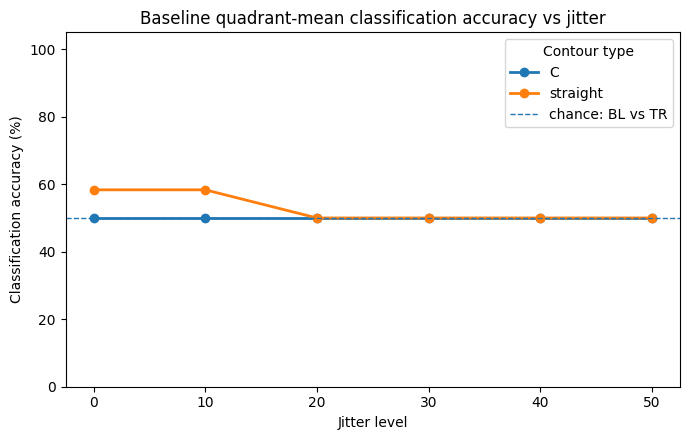

Saved: /home/yentl/pytorch_gammanet/outputs_jitter_quadrant_mean_classification_standalone/plots/baseline_quadrant_mean_accuracy_vs_jitter_C_vs_straight.png


In [7]:
# ============================================================
# 7. Plot: BASELINE accuracy vs jitter
# ============================================================
plt.figure(figsize=(7, 4.5))

for contour_type in CONTOURS:
    sub = baseline_summary_df[baseline_summary_df["contour_type"] == contour_type].sort_values("jitter")

    plt.plot(
        sub["jitter"],
        sub["proportion_match"] * 100,
        marker="o",
        linewidth=2,
        label=contour_type,
    )

plt.axhline(50, linestyle="--", linewidth=1, label="chance: BL vs TR")
plt.xticks(JITTER_LEVELS)
plt.ylim(0, 105)
plt.xlabel("Jitter level")
plt.ylabel("Classification accuracy (%)")
plt.title("Baseline quadrant-mean classification accuracy vs jitter")
plt.legend(title="Contour type")
plt.tight_layout()

plot_path = PLOT_DIR / "baseline_quadrant_mean_accuracy_vs_jitter_C_vs_straight.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", plot_path)


In [8]:
# ============================================================
# 8. Run MATCHED-BIAS quadrant-mean classification, bias strength = 0.25
# ============================================================
bias_records = []

for _, row in tqdm(image_df.iterrows(), total=len(image_df), desc="Matched-bias quadrant-mean classification"):
    record, pil_img, fmap, q_means = classify_one_image_by_quadrant_mean(row, condition="matched_bias")
    bias_records.append(record)

    if SAVE_QUADRANT_VISUALS:
        save_path = (
            VIS_DIR
            / f"matched_bias_{BIAS_STRENGTH}"
            / row["contour_type"]
            / f"J{int(row['jitter']):03d}"
            / f"matched_bias_quadrant_means_{Path(row['filename']).stem}.png"
        )
        save_quadrant_mean_visual(row, f"matched_bias_{BIAS_STRENGTH}", pil_img, fmap, q_means, save_path)

bias_df = pd.DataFrame(bias_records)
bias_results_path = CSV_DIR / f"matched_bias_{BIAS_STRENGTH}_jitter_quadrant_mean_classification_per_image.csv"
bias_df.to_csv(bias_results_path, index=False)
print("Saved:", bias_results_path)

bias_summary_df = summarize_by_jitter(bias_df)
bias_summary_path = CSV_DIR / f"matched_bias_{BIAS_STRENGTH}_jitter_quadrant_mean_classification_summary_by_jitter.csv"
bias_summary_df.to_csv(bias_summary_path, index=False)
print("Saved:", bias_summary_path)

display(bias_summary_df)


Matched-bias quadrant-mean classification: 100%|██████████| 144/144 [16:40<00:00,  6.95s/it]

Saved: /home/yentl/pytorch_gammanet/outputs_jitter_quadrant_mean_classification_standalone/csv/matched_bias_0.25_jitter_quadrant_mean_classification_per_image.csv
Saved: /home/yentl/pytorch_gammanet/outputs_jitter_quadrant_mean_classification_standalone/csv/matched_bias_0.25_jitter_quadrant_mean_classification_summary_by_jitter.csv


,contour_type,jitter,n_images,n_match,proportion_match,mean_activation_BL,mean_activation_TR,mean_activation_TL,mean_activation_BR,mean_highest_compared_quadrant_activation,mean_true_quadrant_activation,mean_activation_difference_BL_minus_TR
0,C,0,12,6,0.500000,2.741386,2.475291,2.573592,2.501799,2.741386,2.688756,0.266095
1,C,10,12,6,0.500000,2.738446,2.471574,2.577196,2.504842,2.738446,2.678919,0.266873
2,C,20,12,6,0.500000,2.738196,2.464623,2.581309,2.507814,2.738196,2.667211,0.273573
3,C,30,12,6,0.500000,2.724594,2.459404,2.591869,2.515613,2.724594,2.639649,0.265190
4,C,40,12,6,0.500000,2.712859,2.462911,2.595189,2.519406,2.712859,2.626078,0.249948
5,C,50,12,6,0.500000,2.710551,2.457703,2.600239,2.522450,2.710551,2.615693,0.252848
6,straight,0,12,8,0.666667,2.736083,2.514989,2.624462,2.518705,2.739722,2.719312,0.221094
7,straight,10,12,7,0.583333,2.735186,2.501656,2.636616,2.527274,2.735259,2.693852,0.233530
8,straight,20,12,6,0.500000,2.734396,2.493008,2.641691,2.531417,2.734396,2.679892,0.241388
9,straight,30,12,6,0.500000,2.732311,2.482718,2.649505,2.536789,2.732311,2.660933,0.249593


Saved: /home/yentl/pytorch_gammanet/outputs_jitter_quadrant_mean_classification_standalone/csv/baseline_vs_matched_bias_0.25_quadrant_mean_summary_by_jitter.csv


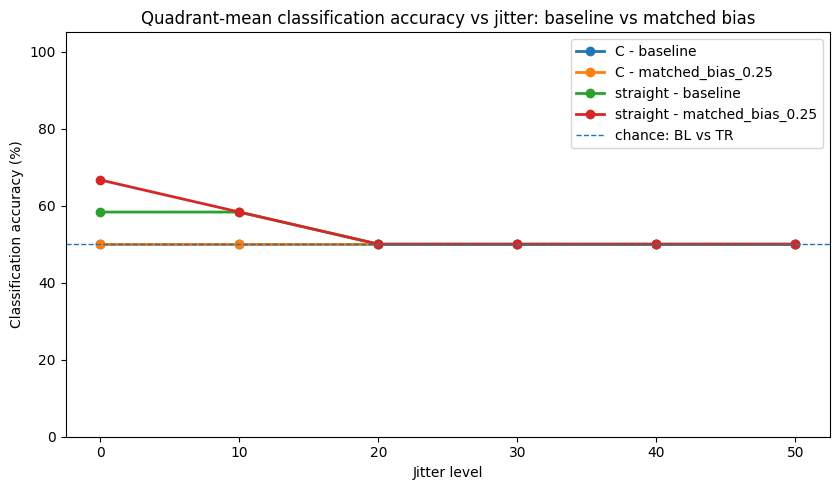

Saved: /home/yentl/pytorch_gammanet/outputs_jitter_quadrant_mean_classification_standalone/plots/baseline_vs_matched_bias_0.25_quadrant_mean_accuracy_vs_jitter.png


,contour_type,jitter,n_images,n_match,proportion_match,mean_activation_BL,mean_activation_TR,mean_activation_TL,mean_activation_BR,mean_highest_compared_quadrant_activation,mean_true_quadrant_activation,mean_activation_difference_BL_minus_TR,condition
0,C,0,12,6,0.500000,2.350854,2.110345,2.200754,2.129653,2.350854,2.303582,0.240509,baseline
1,C,10,12,6,0.500000,2.347865,2.106961,2.204133,2.132414,2.347865,2.294228,0.240904,baseline
2,C,20,12,6,0.500000,2.346965,2.101425,2.207681,2.134882,2.346965,2.283804,0.245540,baseline
3,C,30,12,6,0.500000,2.333774,2.096866,2.217311,2.141744,2.333774,2.258267,0.236908,baseline
4,C,40,12,6,0.500000,2.322898,2.100280,2.220172,2.144930,2.322898,2.245813,0.222618,baseline
5,C,50,12,6,0.500000,2.320379,2.095692,2.225076,2.147155,2.320379,2.236193,0.224688,baseline
6,straight,0,12,7,0.583333,2.322350,2.122094,2.218655,2.126201,2.325567,2.307537,0.200256,baseline
7,straight,10,12,7,0.583333,2.320692,2.110097,2.228615,2.133098,2.321261,2.284747,0.210595,baseline
8,straight,20,12,6,0.500000,2.319866,2.102747,2.232898,2.136674,2.319866,2.272720,0.217119,baseline
9,straight,30,12,6,0.500000,2.317859,2.092888,2.239882,2.141520,2.317859,2.254976,0.224970,baseline


In [9]:
# ============================================================
# 9. Plot: BASELINE vs MATCHED BIAS accuracy vs jitter
# ============================================================
plot_df = pd.concat(
    [
        baseline_summary_df.assign(condition="baseline"),
        bias_summary_df.assign(condition=f"matched_bias_{BIAS_STRENGTH}"),
    ],
    ignore_index=True,
)

combined_summary_path = CSV_DIR / f"baseline_vs_matched_bias_{BIAS_STRENGTH}_quadrant_mean_summary_by_jitter.csv"
plot_df.to_csv(combined_summary_path, index=False)
print("Saved:", combined_summary_path)

plt.figure(figsize=(8.5, 5))

for contour_type in CONTOURS:
    for condition in ["baseline", f"matched_bias_{BIAS_STRENGTH}"]:
        sub = plot_df[
            (plot_df["contour_type"] == contour_type) &
            (plot_df["condition"] == condition)
        ].sort_values("jitter")

        label = f"{contour_type} - {condition}"

        plt.plot(
            sub["jitter"],
            sub["proportion_match"] * 100,
            marker="o",
            linewidth=2,
            label=label,
        )

plt.axhline(50, linestyle="--", linewidth=1, label="chance: BL vs TR")
plt.xticks(JITTER_LEVELS)
plt.ylim(0, 105)
plt.xlabel("Jitter level")
plt.ylabel("Classification accuracy (%)")
plt.title("Quadrant-mean classification accuracy vs jitter: baseline vs matched bias")
plt.legend()
plt.tight_layout()

plot_path = PLOT_DIR / f"baseline_vs_matched_bias_{BIAS_STRENGTH}_quadrant_mean_accuracy_vs_jitter.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", plot_path)

display(plot_df)


## Output

De belangrijkste outputbestanden staan in:

```text
/home/yentl/pytorch_gammanet/outputs_jitter_quadrant_mean_classification_standalone/
```

Belangrijkste CSV's:

```text
csv/baseline_jitter_quadrant_mean_classification_summary_by_jitter.csv
csv/matched_bias_0.25_jitter_quadrant_mean_classification_summary_by_jitter.csv
csv/baseline_vs_matched_bias_0.25_quadrant_mean_summary_by_jitter.csv
```

Belangrijkste plots:

```text
plots/baseline_quadrant_mean_accuracy_vs_jitter_C_vs_straight.png
plots/baseline_vs_matched_bias_0.25_quadrant_mean_accuracy_vs_jitter.png
```

Per-image resultaten staan ook in de `csv/` map. Daarin zie je per afbeelding de mean activatie in `TL`, `TR`, `BL` en `BR`, maar de voorspelling wordt alleen gemaakt uit `BL` versus `TR`.